In [28]:
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

train_df=pd.read_csv("/kaggle/input/competitions/dev-comm-jc-2026/train.csv")
test_df=pd.read_csv("/kaggle/input/competitions/dev-comm-jc-2026/test.csv")

In [29]:
#BASIC UNDERSTANDING OF DATA
train_df.describe()
train_df.info()
train_df.head
train_df.shape
train_df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

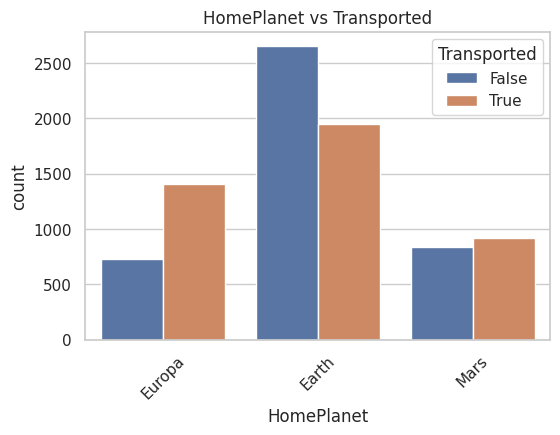

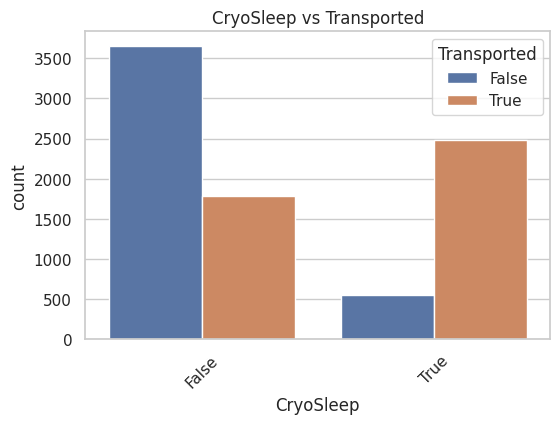

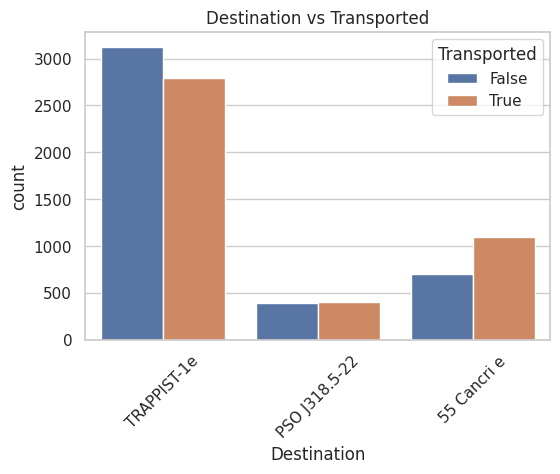

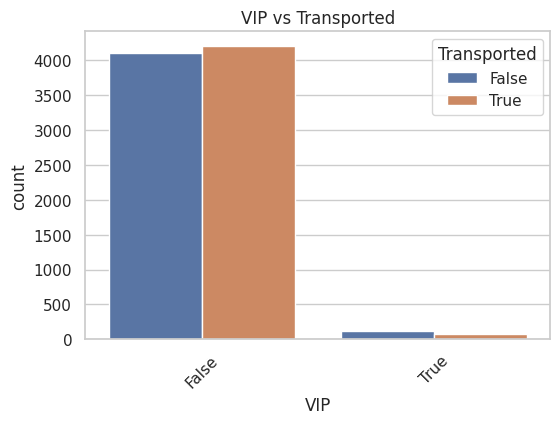


Crosstab for VIP:
 Transported     False     True 
VIP                            
False        0.493668  0.506332
True         0.618090  0.381910


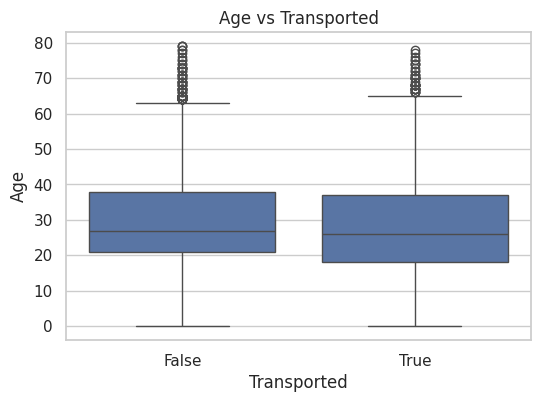

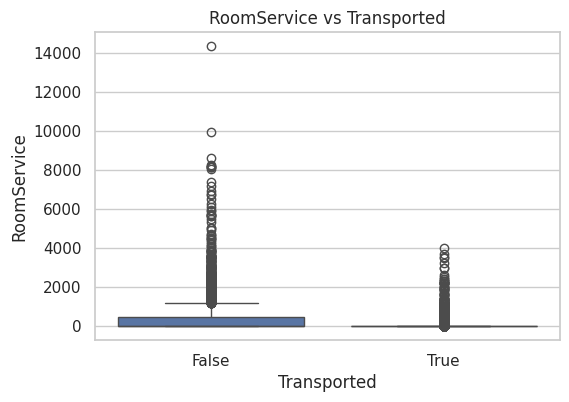

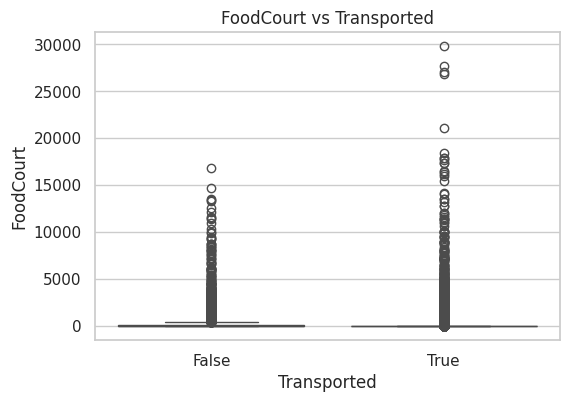

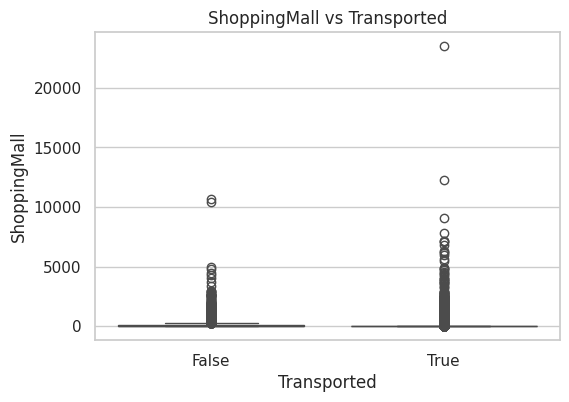

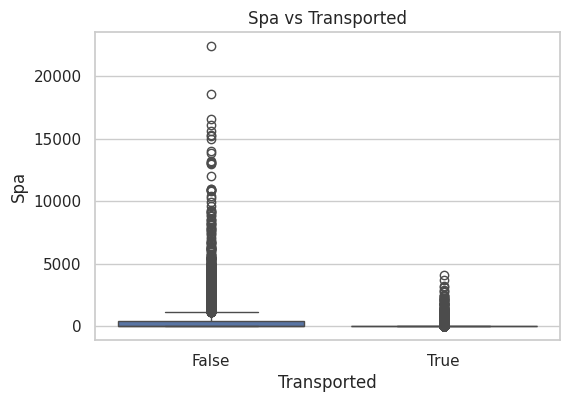

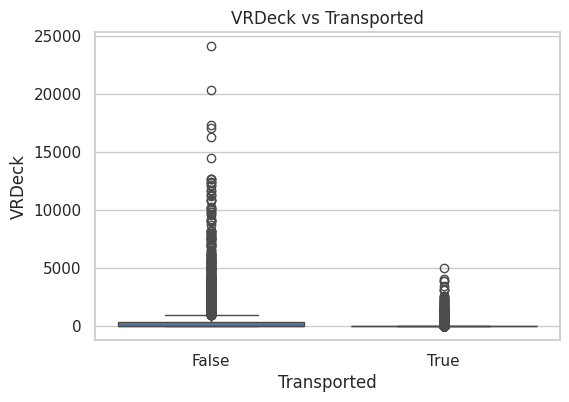

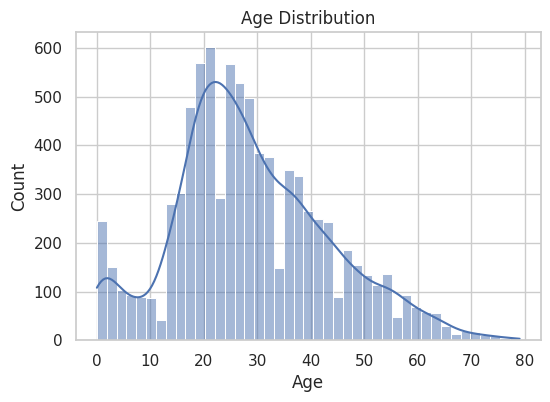

In [30]:
#BASIC VISUALISATION
cat_cols = ["HomePlanet", "CryoSleep", "Destination", "VIP"]
target = "Transported"
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data=train_df, x=col, hue=target)
    plt.title(f"{col} vs Transported")
    plt.xticks(rotation=45)
    plt.show()

ct = pd.crosstab(train_df[col], train_df[target], normalize="index")
print(f"\nCrosstab for {col}:\n", ct)

num_cols = ["Age","RoomService","FoodCourt","ShoppingMall","Spa","VRDeck"]

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=train_df[target], y=train_df[col])
    plt.title(f"{col} vs Transported")
    plt.show()

plt.figure(figsize=(6,4))
sns.histplot(train_df['Age'], kde=True)
plt.title("Age Distribution")
plt.show()

In [31]:
#DATA PREPROCESSING
def preprocess(df, bins=None, fit_bins=False):
    df=df.copy()

    df.drop("Name",axis=1,inplace=True,errors='ignore')

    # Group features
    df["Group"]=df["PassengerId"].str.split("_").str[0]
    df["GroupSize"]=df.groupby("Group")["Group"].transform("size")

    # Age
    df["Age"]=df.groupby("HomePlanet")["Age"].transform(lambda x: x.fillna(x.median()))

    # Destination
    df["Destination"]=df.groupby("Group")["Destination"].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else "Unknown"))

    # Cabin split
    df[["Deck","CabinNum","Side"]]=df["Cabin"].str.split("/", expand=True)

    df["Deck"]=df.groupby("Group")["Deck"].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else "Unknown"))
    df['Side'].fillna('Unknown',inplace=True)

    df["HomePlanet"]=df.groupby("Deck")["HomePlanet"].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else "Unknown"))

    df["DeckSide"]=df["Deck"].astype(str) + "_" + df["Side"].astype(str)
    df["CabinNumCount"]=df.groupby("CabinNum")["CabinNum"].transform("count")

    # CabinNum numeric
    df["CabinNum"]=pd.to_numeric(df["CabinNum"], errors="coerce")
    df["CabinNum"]=df["CabinNum"].fillna(df["CabinNum"].median())
    df['IsAlone']=(df['GroupSize'] == 1).astype(int)

    if fit_bins:
        df["CabinRegion"],bins=pd.qcut(df["CabinNum"],q=5,labels=False,retbins=True,duplicates="drop")
    else:
        df["CabinRegion"]=pd.cut(df["CabinNum"],bins=bins,labels=False)

    df['AgeBand']=pd.cut(df['Age'],bins=[0,12,18,35,60,100]).astype(str)

    # Fill numeric
    num_cols=df.select_dtypes(include=['int64','float64']).columns
    for col in num_cols:
        df[col] = df[col].fillna(df[col].median())

    # Spend features
    df["TotalSpend"]=df[["RoomService", "ShoppingMall", "Spa", "VRDeck","FoodCourt"]].sum(axis=1)
    df["GroupSpend"]=df.groupby("Group")["TotalSpend"].transform("mean")
    df['NoSpend']=(df['TotalSpend']==0).astype(int)
    
    df["LuxurySpend"]=df["Spa"]+df["VRDeck"]
    df["BasicSpend"]=df["RoomService"]+df["FoodCourt"]+df["ShoppingMall"]
    df["LuxuryRatio"]=df["LuxurySpend"]/(df["TotalSpend"]+1)
    
    df["LogSpend"]=np.log1p(df["TotalSpend"])
    df["LogCabinNum"]=np.log1p(df["CabinNum"])
    
    # CryoSleep
    df.loc[df['CryoSleep'].isna(),'CryoSleep']=np.where(
        df.loc[df['CryoSleep'].isna(), 'TotalSpend'] == 0,True,False)

    # VIP
    df['VIP'] = df['VIP'].fillna(df['VIP'].mode()[0])

    # Fill categorical
    cat_cols = df.select_dtypes(include=['object']).columns
    for col in cat_cols:
        df[col] = df[col].fillna("Unknown")

    # Combo
    df['combo'] = (df['HomePlanet'].astype(str) + "_" +df['CryoSleep'].astype(str) + "_" +
        df['VIP'].astype(str)
    )

    return df, bins if fit_bins else df


In [32]:

pd.crosstab(train_df['CryoSleep'],train_df['Transported'],normalize='index')

Transported,False,True
CryoSleep,,
False,0.671079,0.328921
True,0.182417,0.817583



Fold 1


/tmp/ipykernel_58/3374756416.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Side'].fillna('Unknown',inplace=True)
/tmp/ipykernel_58/3374756416.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['VIP'] = df['VIP'].fillna(df['VIP'].mode()[0])
/tmp/ipykernel_58/3374756416.py:67: FutureWarning: Downc

Accuracy:  0.8051
Precision: 0.8233
Recall:    0.7989
F1 Score:  0.8109


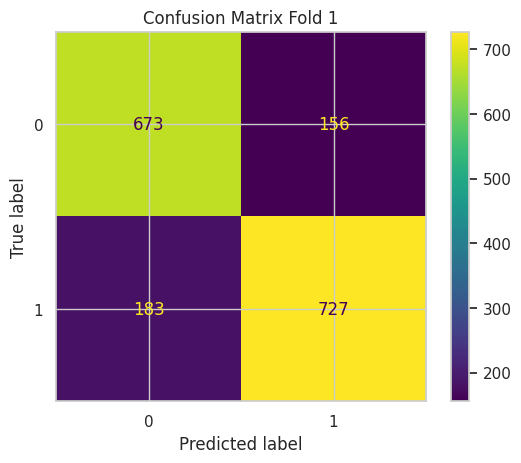


Fold 2


/tmp/ipykernel_58/3374756416.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Side'].fillna('Unknown',inplace=True)
/tmp/ipykernel_58/3374756416.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['VIP'] = df['VIP'].fillna(df['VIP'].mode()[0])
/tmp/ipykernel_58/3374756416.py:67: FutureWarning: Downc

Accuracy:  0.7941
Precision: 0.7870
Recall:    0.8189
F1 Score:  0.8026


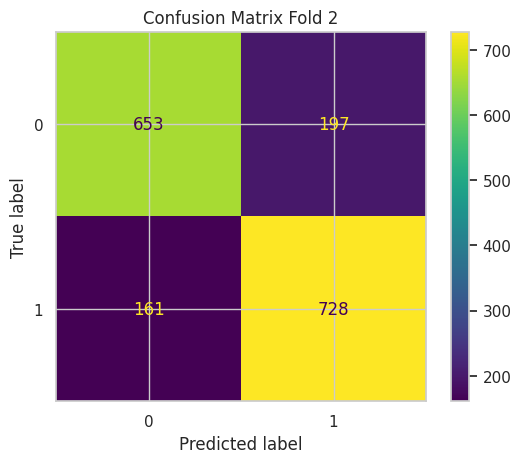


Fold 3


/tmp/ipykernel_58/3374756416.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Side'].fillna('Unknown',inplace=True)
/tmp/ipykernel_58/3374756416.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['VIP'] = df['VIP'].fillna(df['VIP'].mode()[0])
/tmp/ipykernel_58/3374756416.py:67: FutureWarning: Downc

Accuracy:  0.8269
Precision: 0.8232
Recall:    0.8299
F1 Score:  0.8265


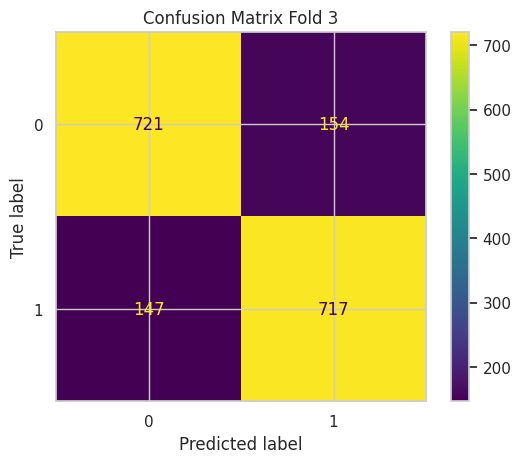


Fold 4


/tmp/ipykernel_58/3374756416.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Side'].fillna('Unknown',inplace=True)
/tmp/ipykernel_58/3374756416.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['VIP'] = df['VIP'].fillna(df['VIP'].mode()[0])
/tmp/ipykernel_58/3374756416.py:67: FutureWarning: Downc

Accuracy:  0.8280
Precision: 0.8188
Recall:    0.8423
F1 Score:  0.8304


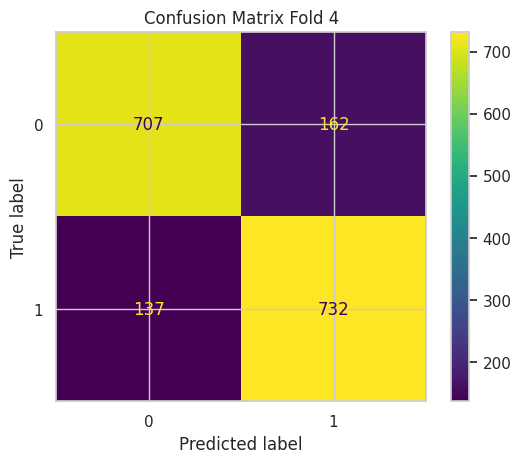


Fold 5


/tmp/ipykernel_58/3374756416.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Side'].fillna('Unknown',inplace=True)
/tmp/ipykernel_58/3374756416.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['VIP'] = df['VIP'].fillna(df['VIP'].mode()[0])
/tmp/ipykernel_58/3374756416.py:67: FutureWarning: Downc

Accuracy:  0.8239
Precision: 0.8230
Recall:    0.8132
F1 Score:  0.8181


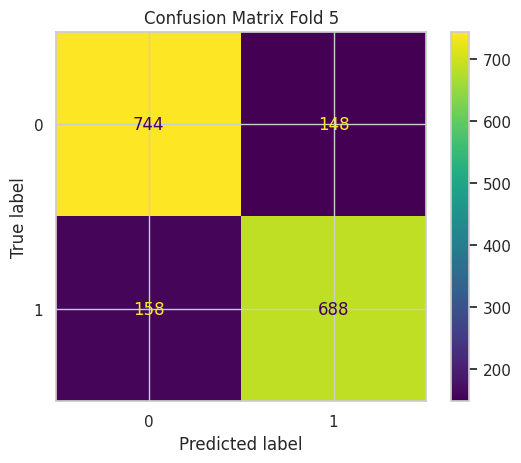

Mean Accuracy:  0.8156 ± 0.0136
Mean Precision: 0.8151 ± 0.0141
Mean Recall:    0.8206 ± 0.0147
Mean F1 Score:  0.8177 ± 0.0101


In [33]:
# MODELING AND CV
y = train_df["Transported"].astype(int)
groups = train_df["PassengerId"].str.split("_").str[0]

gkf = GroupKFold(n_splits=5)

acc_scores = []
prec_scores = []
rec_scores = []
f1_scores = []

models = []

for fold, (train_idx, val_idx) in enumerate(gkf.split(train_df, y, groups)):
    print(f"\nFold {fold+1}")

    train_fold = train_df.iloc[train_idx].copy()
    val_fold   = train_df.iloc[val_idx].copy()

    train_fold, bins = preprocess(train_fold, fit_bins=True)
    val_fold, _ = preprocess(val_fold, bins=bins)

    X_train = train_fold.drop(["Transported", "PassengerId"], axis=1)
    y_train = train_fold["Transported"]

    X_val = val_fold.drop(["Transported", "PassengerId"], axis=1)
    y_val = val_fold["Transported"]

    cat_cols = X_train.select_dtypes(include="object").columns.tolist()

    for col in cat_cols:
        X_train[col] = X_train[col].astype(str)
        X_val[col] = X_val[col].astype(str)

    model = CatBoostClassifier(
        iterations=3000,
        learning_rate=0.03,
        depth=6,
        l2_leaf_reg=6,
        eval_metric="Accuracy",
        loss_function="Logloss",
        random_state=42,
        verbose=0
    )

    model.fit(
        X_train, y_train,
        eval_set=(X_val, y_val),
        cat_features=cat_cols,
        early_stopping_rounds=200
    )

    preds = model.predict(X_val)

    acc = accuracy_score(y_val, preds)
    prec = precision_score(y_val, preds)
    rec = recall_score(y_val, preds)
    f1 = f1_score(y_val, preds)

    acc_scores.append(acc)
    prec_scores.append(prec)
    rec_scores.append(rec)
    f1_scores.append(f1)

    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")

    cm = confusion_matrix(y_val, preds)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(f"Confusion Matrix Fold {fold+1}")
    plt.show()

print(f"Mean Accuracy:  {np.mean(acc_scores):.4f} ± {np.std(acc_scores):.4f}")
print(f"Mean Precision: {np.mean(prec_scores):.4f} ± {np.std(prec_scores):.4f}")
print(f"Mean Recall:    {np.mean(rec_scores):.4f} ± {np.std(rec_scores):.4f}")
print(f"Mean F1 Score:  {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")

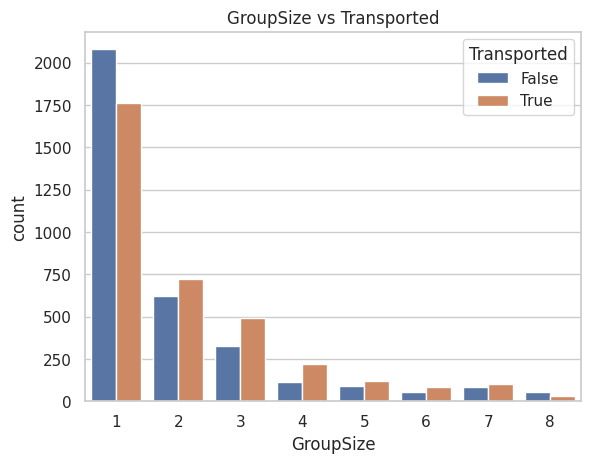

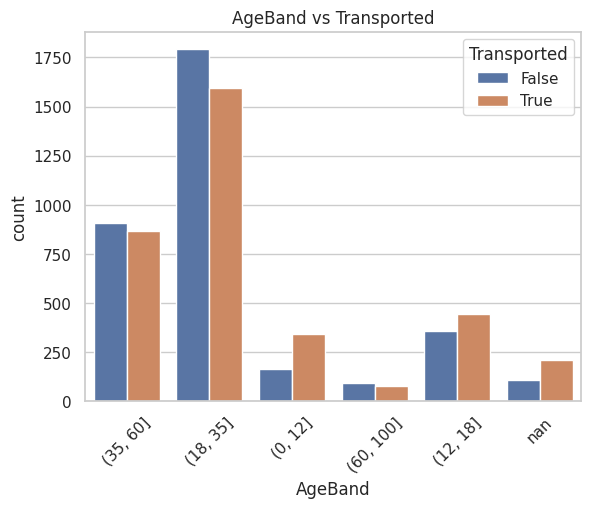

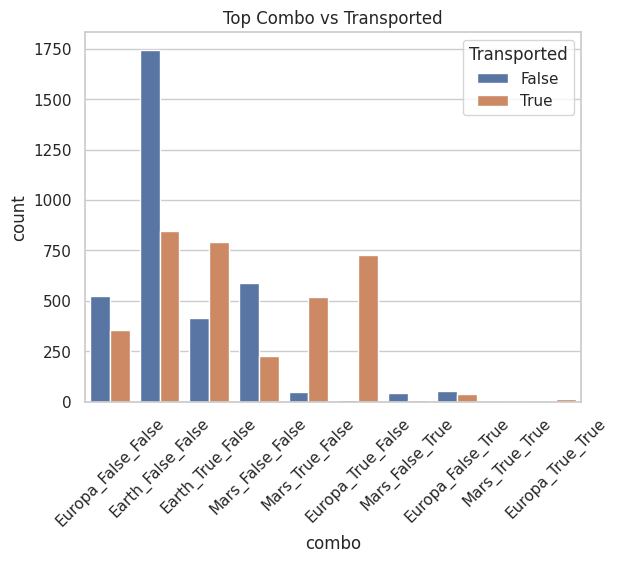

In [34]:
#EDA, FINDING CORRELATIONS IN DATA FOR FEATURE ENGINEERING 

sns.countplot(x=train_fold["GroupSize"], hue=train_fold["Transported"])
plt.title("GroupSize vs Transported")
plt.show()


sns.countplot(x=train_fold["AgeBand"], hue=train_fold["Transported"])
plt.xticks(rotation=45)
plt.title("AgeBand vs Transported")
plt.show()


top_combo = train_fold["combo"].value_counts().head(10).index
sns.countplot(data=train_fold[train_fold["combo"].isin(top_combo)],
              x="combo", hue="Transported")
plt.xticks(rotation=45)
plt.title("Top Combo vs Transported")
plt.show()


Destination  55 Cancri e  PSO J318.5-22  TRAPPIST-1e   Unknown
HomePlanet                                                    
Earth           0.153461       0.155830     0.675178  0.015530
Europa          0.418848       0.008144     0.564282  0.008726
Mars            0.115518       0.025748     0.848991  0.009743


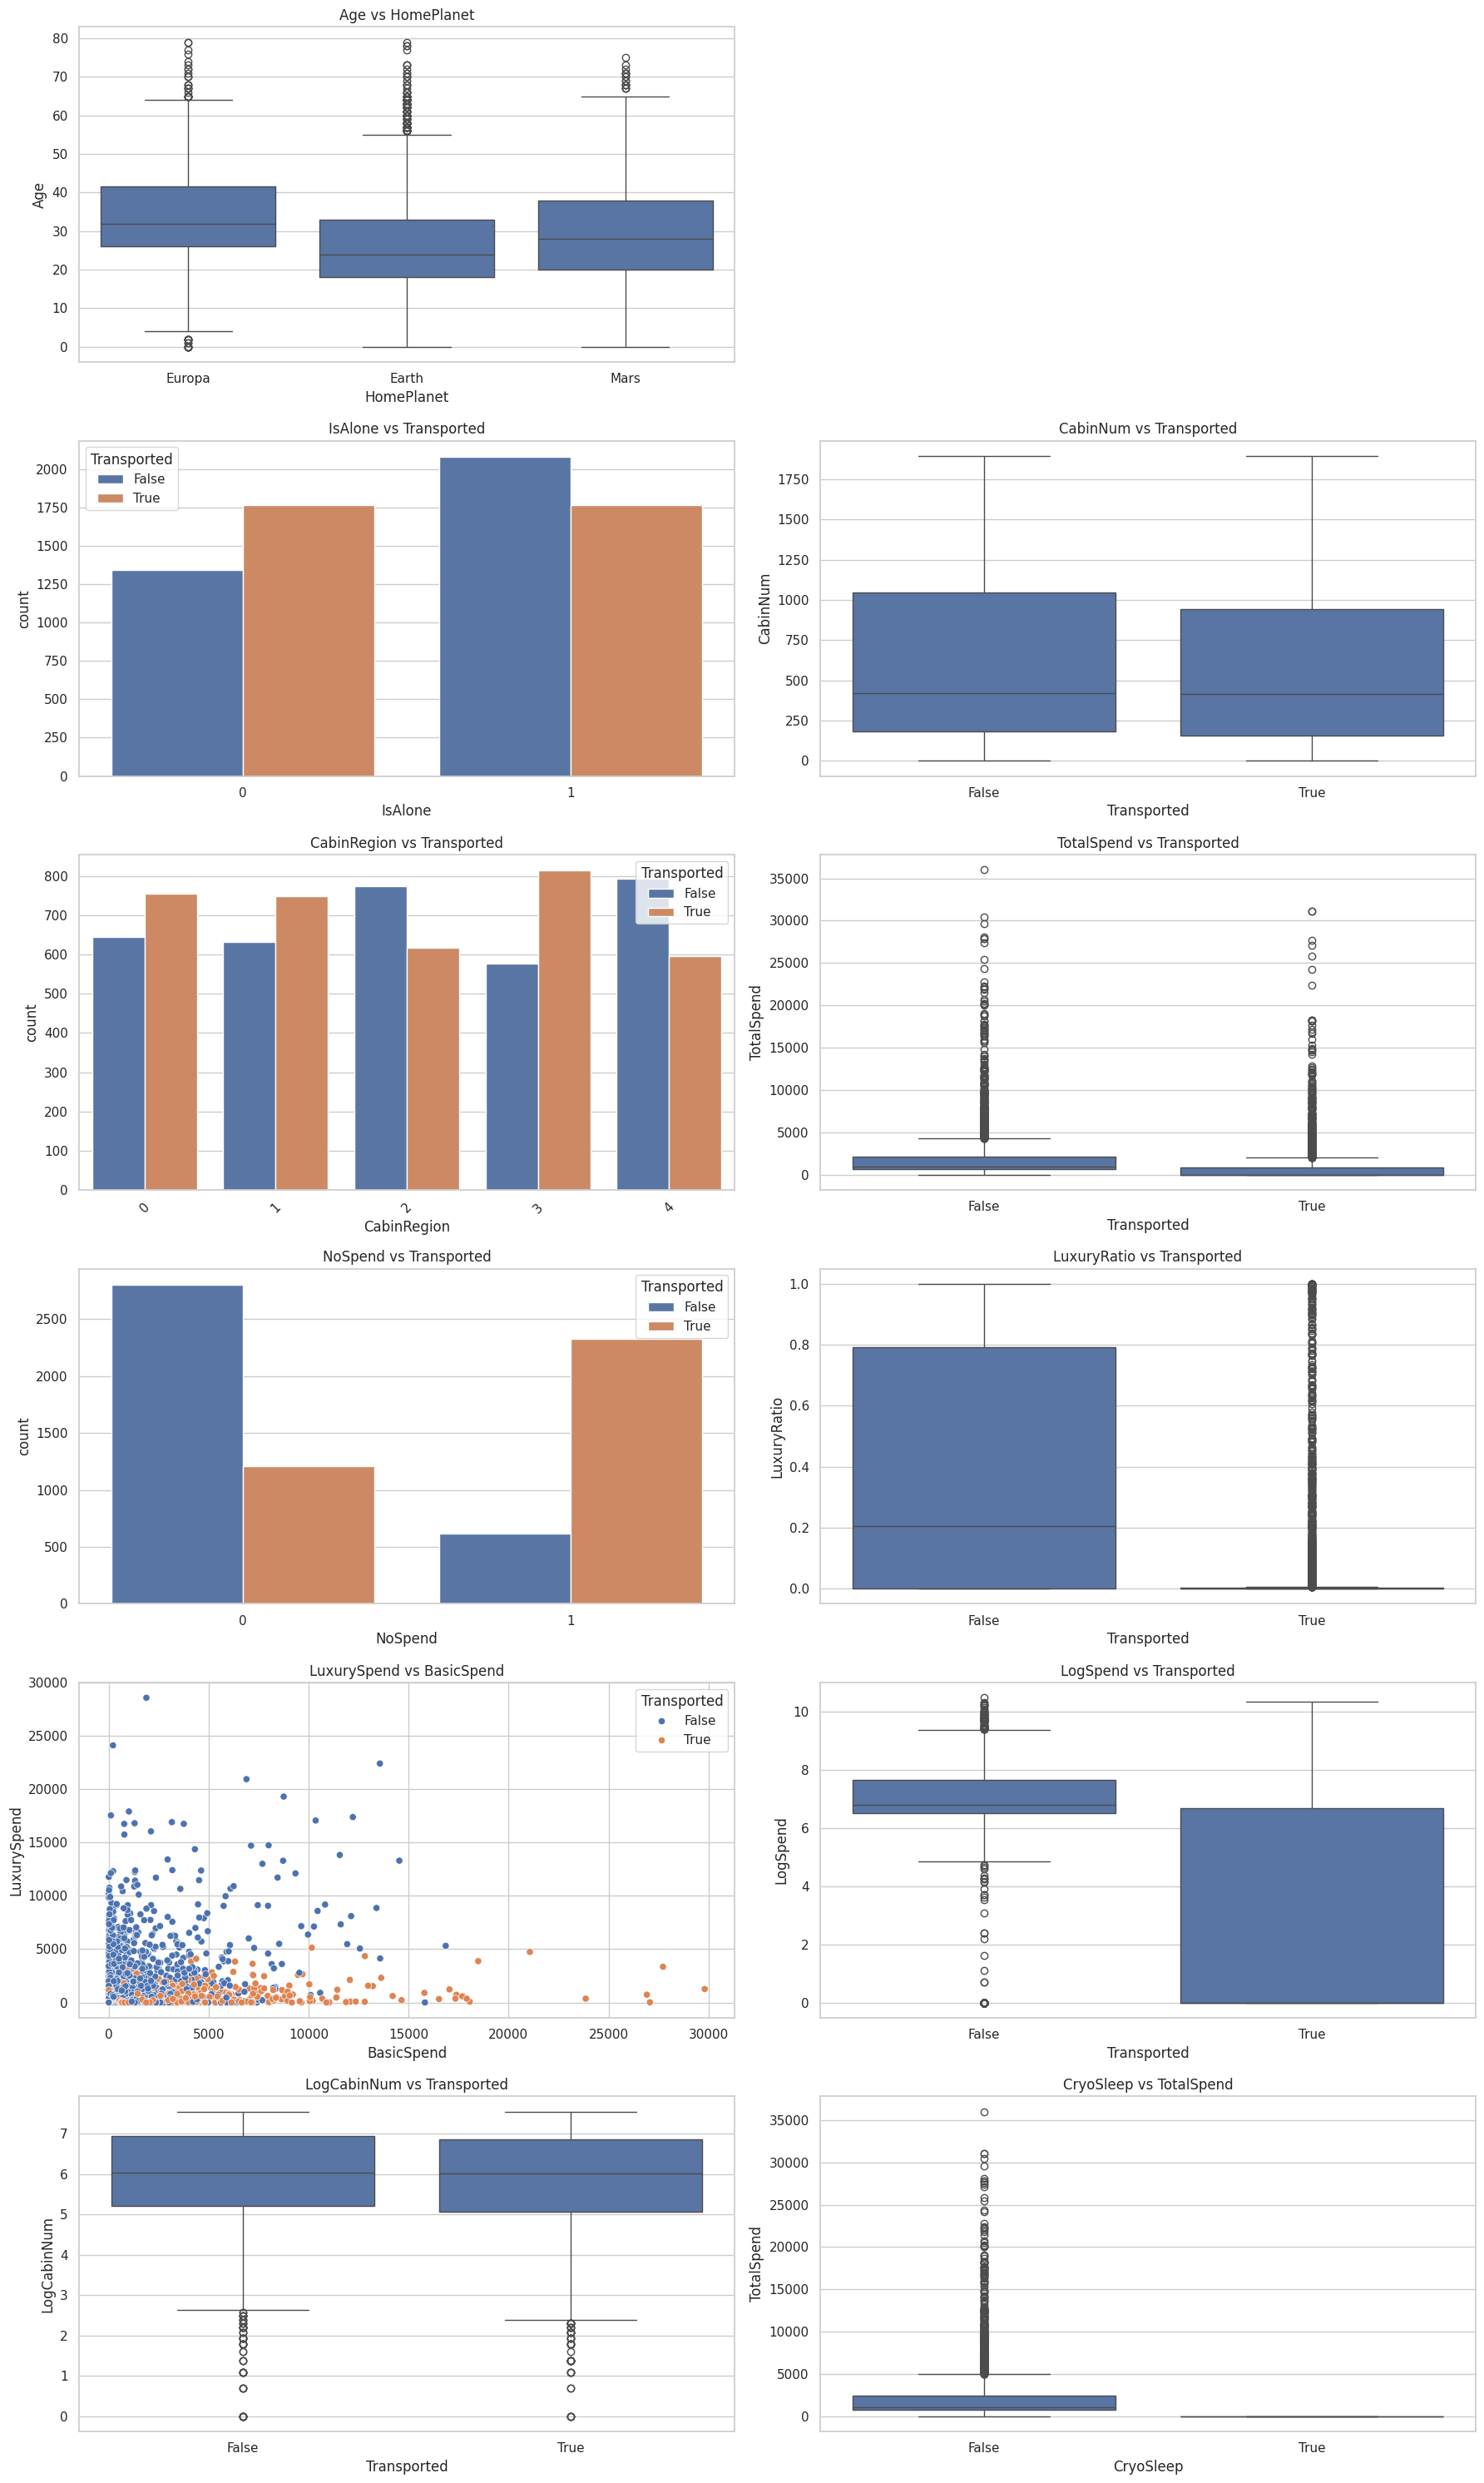


HomePlanet + CryoSleep + VIP vs Transported:
 Transported                    False     True 
HomePlanet CryoSleep VIP                      
Earth      False     False  0.673477  0.326523
                     True   1.000000  0.000000
           True      False  0.343023  0.656977
Europa     False     False  0.596351  0.403649
                     True   0.586957  0.413043
           True      False  0.008163  0.991837
                     True   0.000000  1.000000
Mars       False     False  0.720930  0.279070
                     True   0.836735  0.163265
           True      False  0.085965  0.914035
                     True   0.000000  1.000000


In [37]:
sns.set(style="whitegrid")

fig, axes = plt.subplots(6, 2, figsize=(18, 30))
axes = axes.flatten()
sns.boxplot(x='HomePlanet', y='Age', data=train_fold, ax=axes[0])
axes[0].set_title("Age vs HomePlanet")

ct1=pd.crosstab(train_fold['HomePlanet'], train_fold['Destination'],normalize='index')
print(ct1)

sns.countplot(x='IsAlone', hue='Transported', data=train_fold, ax=axes[2])
axes[2].set_title("IsAlone vs Transported")

sns.boxplot(x='Transported', y='CabinNum', data=train_fold, ax=axes[3])
axes[3].set_title("CabinNum vs Transported")

sns.countplot(x='CabinRegion', hue='Transported', data=train_fold, ax=axes[4])
axes[4].set_title("CabinRegion vs Transported")
axes[4].tick_params(axis='x', rotation=45)

sns.boxplot(x='Transported', y='TotalSpend', data=train_fold, ax=axes[5])
axes[5].set_title("TotalSpend vs Transported")

sns.countplot(x='NoSpend', hue='Transported', data=train_fold, ax=axes[6])
axes[6].set_title("NoSpend vs Transported")

sns.boxplot(x='Transported', y='LuxuryRatio', data=train_fold, ax=axes[7])
axes[7].set_title("LuxuryRatio vs Transported")

sns.scatterplot(x='BasicSpend', y='LuxurySpend', hue='Transported', data=train_fold, ax=axes[8])
axes[8].set_title("LuxurySpend vs BasicSpend")

sns.boxplot(x='Transported', y='LogSpend', data=train_fold, ax=axes[9])
axes[9].set_title("LogSpend vs Transported")

sns.boxplot(x='Transported', y='LogCabinNum', data=train_fold, ax=axes[10])
axes[10].set_title("LogCabinNum vs Transported")

sns.boxplot(x='CryoSleep', y='TotalSpend', data=train_fold, ax=axes[11])
axes[11].set_title("CryoSleep vs TotalSpend")

for ax in axes:
    if not ax.has_data():
        ax.set_visible(False)

plt.tight_layout()
plt.show()


ct3 = pd.crosstab(
    [train_fold['HomePlanet'], train_fold['CryoSleep'], train_fold['VIP']],
    train_fold['Transported'],
    normalize='index'
)
print("\nHomePlanet + CryoSleep + VIP vs Transported:\n", ct3)

In [ ]:
test_ids = test_df["PassengerId"]

test_df, _ = preprocess(test_df, bins=bins)

X_test = test_df.drop("PassengerId", axis=1)

for col in cat_cols:
    X_test[col] = X_test[col].astype(str)

preds = np.mean([m.predict(X_test) for m in models], axis=0)
preds = preds.astype(bool)

submission = pd.DataFrame({
    "PassengerId": test_ids,
    "Transported": preds
})

submission.to_csv("submission_final5.csv", index=False)